In [1]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train_processed.csv")
w2_df = pd.read_csv("../data/processed/w2_processed.csv")
w3_df = pd.read_csv("../data/processed/w3_processed.csv")

print(f"Train Shape : {train_df.shape}")
print(f"W2 Shape    : {w2_df.shape}")
print(f"W3 Shape    : {w3_df.shape}")

Train Shape : (452048, 55)
W2 Shape    : (175067, 55)
W3 Shape    : (165750, 55)


In [2]:
X_train = train_df.drop(columns="isFraud")
y_train = train_df["isFraud"]

X_w2 = w2_df.drop(columns="isFraud")
y_w2 = w2_df["isFraud"]

X_w3 = w3_df.drop(columns="isFraud")
y_w3 = w3_df["isFraud"]

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_w2    : {X_w2.shape} | y_w2    : {y_w2.shape}")
print(f"X_w3    : {X_w3.shape} | y_w3    : {y_w3.shape}")

X_train : (452048, 54) | y_train : (452048,)
X_w2    : (175067, 54) | y_w2    : (175067,)
X_w3    : (165750, 54) | y_w3    : (165750,)


In [3]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier

from xgboost import XGBClassifier



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import time

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob),
        "Train Time (sec)": train_time,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

    return results

In [5]:

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "AdaBoost"            : AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost"             : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='aucpr', verbosity=0)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    results[name] = evaluate_model(model, X_train, y_train, X_w2, y_w2)
    print(f"{name} done. PR AUC: {results[name]['PR AUC']}")

results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON ===")
print(results_df.sort_values("PR AUC", ascending=False))

Training Logistic Regression...
Logistic Regression done. PR AUC: 0.3162028896834952
Training Random Forest...
Random Forest done. PR AUC: 0.4946840515610869
Training AdaBoost...
AdaBoost done. PR AUC: 0.34355933772915315
Training XGBoost...
XGBoost done. PR AUC: 0.46335417159841213

=== MODEL COMPARISON ===
                     Accuracy  Precision    Recall  F1 Score   ROC AUC  \
Random Forest        0.969932   0.784049  0.334053  0.468498  0.861573   
XGBoost              0.958399   0.473012  0.426494  0.448550  0.853960   
AdaBoost             0.827917   0.137310  0.631821  0.225593  0.808048   
Logistic Regression  0.548590   0.068867  0.828942  0.127169  0.791737   

                       PR AUC  Train Time (sec)      TP       FP      FN  \
Random Forest        0.494684         60.990263  2320.0    639.0  4625.0   
XGBoost              0.463354          6.312707  2962.0   3300.0  3983.0   
AdaBoost             0.343559        109.493803  4388.0  27569.0  2557.0   
Logistic Regres

In [6]:

from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, classification_report

best_model = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='aucpr', verbosity=0, n_jobs=-1)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_w2)
y_prob = best_model.predict_proba(X_w2)[:, 1]

print(f"PR AUC on W2: {average_precision_score(y_w2, y_prob):.4f}")
print(classification_report(y_w2, y_pred))

PR AUC on W2: 0.4634
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    168122
           1       0.47      0.43      0.45      6945

    accuracy                           0.96    175067
   macro avg       0.72      0.70      0.71    175067
weighted avg       0.96      0.96      0.96    175067



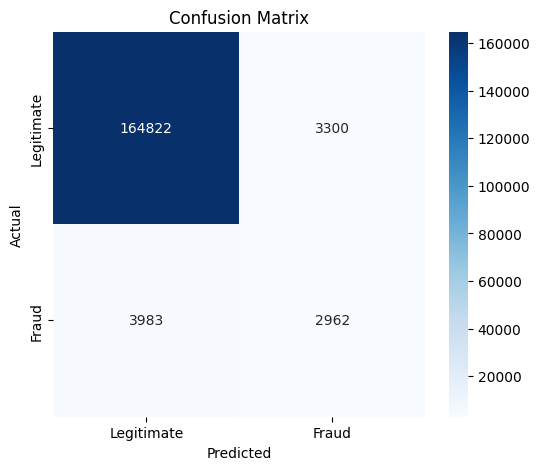

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_w2, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate','Fraud'],
    yticklabels=['Legitimate','Fraud']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

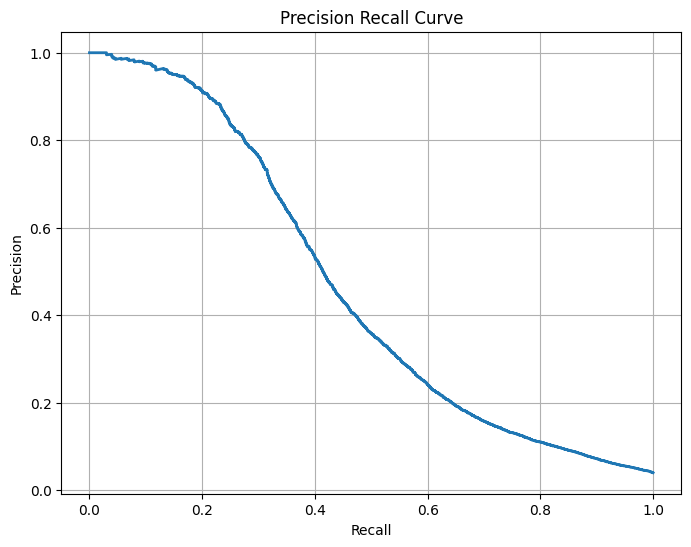

In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_w2,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.grid(True)

plt.show()

In [9]:

# THRESHOLD TUNING


from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_w2, y_prob)

threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

threshold_df.head()

,Threshold,Precision,Recall
0,0.000003,0.039671,1.0
1,0.000003,0.039671,1.0
2,0.000004,0.039671,1.0
3,0.000004,0.039671,1.0
4,0.000005,0.039672,1.0


In [10]:

# DISPLAY THRESHOLD TABLE


threshold_df.iloc[::50].reset_index(drop=True)

,Threshold,Precision,Recall
0,0.000003,0.039671,1.000000
1,0.000028,0.039683,1.000000
2,0.000059,0.039695,1.000000
3,0.000078,0.039707,1.000000
4,0.000098,0.039719,1.000000
...,...,...,...
3200,0.996703,0.995614,0.032685
3201,0.997628,1.000000,0.025054
3202,0.998386,1.000000,0.017135
3203,0.999083,1.000000,0.009647


In [11]:

# FIND BEST F1 THRESHOLD


threshold_df["F1"] = (
    2
    * threshold_df["Precision"]
    * threshold_df["Recall"]
) / (
    threshold_df["Precision"]
    + threshold_df["Recall"]
)

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.603982
Precision    0.575022
Recall       0.381857
F1           0.458943
Name: 156174, dtype: float64


In [12]:

# APPLY BEST THRESHOLD


best_threshold = best_row["Threshold"]

print(f"Best Threshold : {best_threshold:.3f}")

y_pred_best = (y_prob >= best_threshold).astype(int)

Best Threshold : 0.604


In [13]:

# CLASSIFICATION REPORT


from sklearn.metrics import classification_report

print(classification_report(y_w2, y_pred_best))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    168122
           1       0.58      0.38      0.46      6945

    accuracy                           0.96    175067
   macro avg       0.77      0.69      0.72    175067
weighted avg       0.96      0.96      0.96    175067



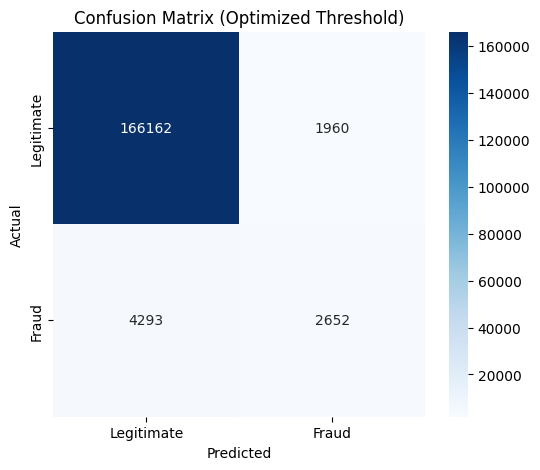

In [14]:
# CONFUSION MATRIX AFTER THRESHOLD TUNING

cm = confusion_matrix(y_w2, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Threshold)")

plt.show()

In [15]:
!pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.66.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.48.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   --- ------------------------------------ 3.9/41.9 MB 47.1 MB/s eta 0:00:01
   ----- ---------------------------------- 5.8/41.9 MB 32.0 MB/s eta 0:00:02
   --------- ------------------------------ 10.0/41.9 MB 19.4 MB/s eta 0:00:02
   ----------- -------------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [16]:
import shap
import matplotlib.pyplot as plt

In [17]:
import shap

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_model)

# Use only a sample for faster visualization
sample = X_w2.sample(1000, random_state=42)

shap_values = explainer.shap_values(sample)

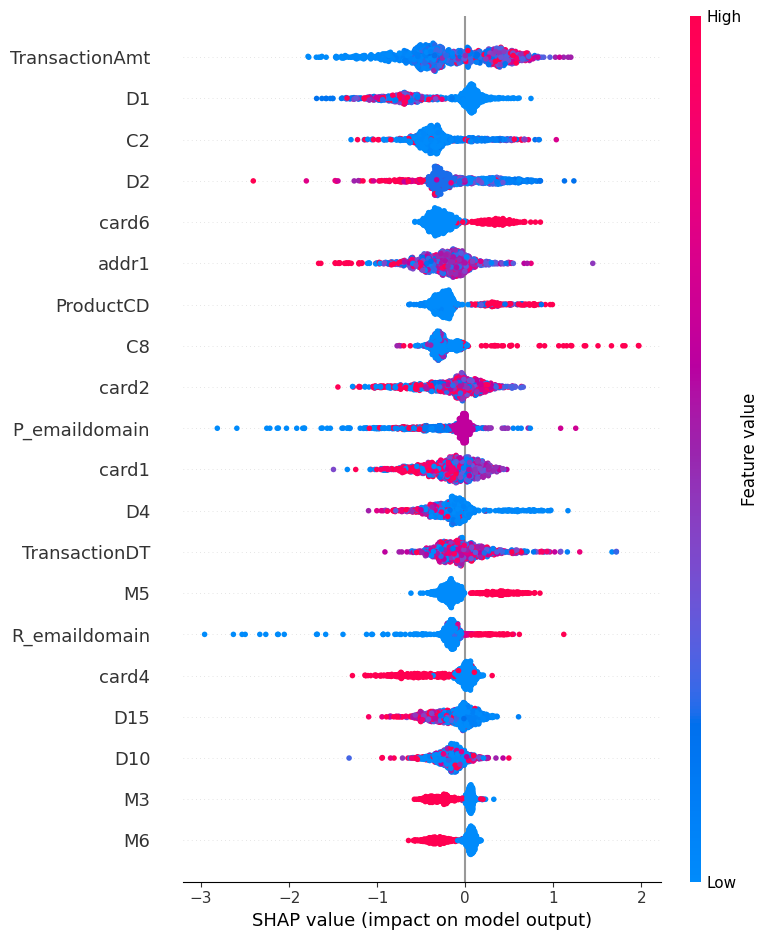

In [18]:
shap.summary_plot(
    shap_values,
    sample
)

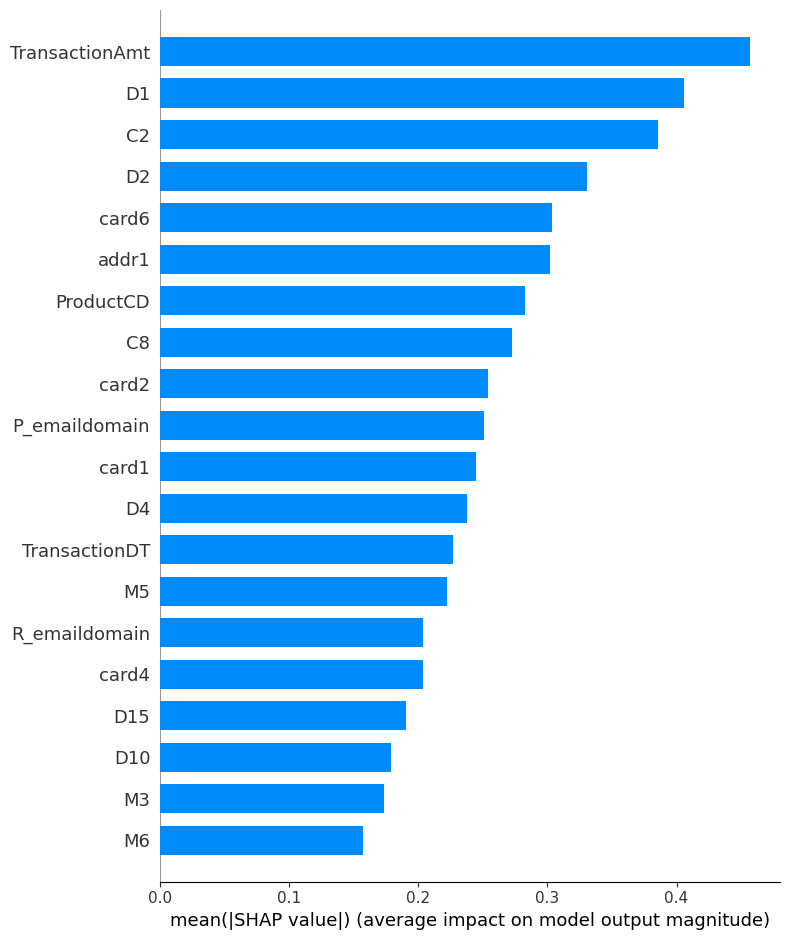

In [19]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

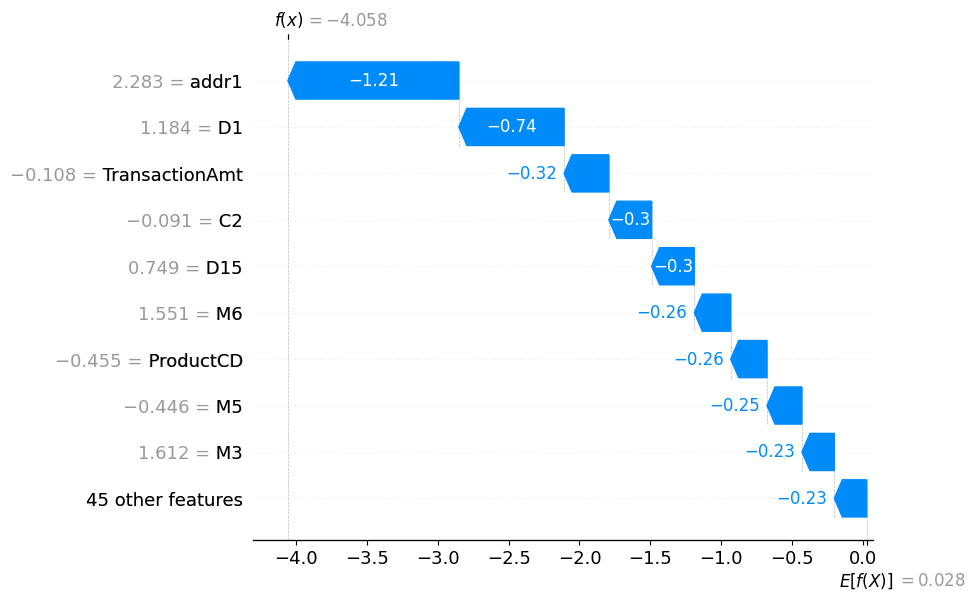

In [20]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

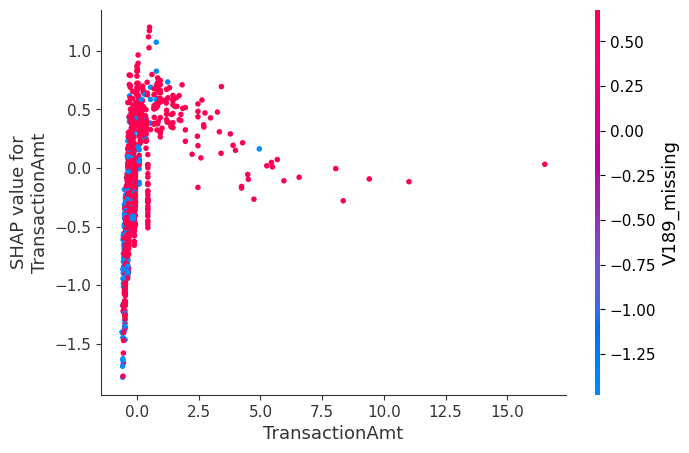

In [21]:
shap.dependence_plot(
    "TransactionAmt",   # Replace with your top feature if different
    shap_values,
    sample
)

In [22]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(best_model, "../artifacts/fraud_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [25]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(best_model, "../artifacts/fraud_model.pkl")
joblib.dump(0.5, "../artifacts/threshold.pkl")

print("Model and threshold saved successfully.")

Model and threshold saved successfully.


In [26]:
#save the metrics
import json
import os

metrics = {
    "Accuracy": float(accuracy_score(y_w2, y_pred)),
    "Precision": float(precision_score(y_w2, y_pred)),
    "Recall": float(recall_score(y_w2, y_pred)),
    "F1": float(f1_score(y_w2, y_pred)),
    "ROC_AUC": float(roc_auc_score(y_w2, y_prob)),
    "PR_AUC": float(average_precision_score(y_w2, y_prob))
}

os.makedirs("../artifacts", exist_ok=True)

with open("../artifacts/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print(metrics)
print("Metrics saved successfully.")

{'Accuracy': 0.9583987844653761, 'Precision': 0.47301181731076336, 'Recall': 0.42649388048956083, 'F1': 0.4485500113576134, 'ROC_AUC': 0.8539601478507384, 'PR_AUC': 0.46335417159841213}
Metrics saved successfully.
